In [1]:
import os
import netCDF4 as netcdf
import numpy as np
import sys
maindir = os.getcwd()
sys.path.append(maindir+"/src")

PATH = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP/Training-Ext/Omon/tos'

In [2]:
DIR_LIST = os.listdir(PATH)

dic_data = {}
dic_forced_response = {}

# how to center the data with respect to the monthly mean

# 1. calculate the monthly mean
# 2. subtract the monthly mean from the data
# 3. calculate the forced response by averaging over the time dimension

for idx_m, dir in enumerate(DIR_LIST):

    print(f'Processing {idx_m+1}/{len(DIR_LIST)}: {dir}')
    dir_path = os.path.join(PATH, dir)
    file_list = os.listdir(dir_path)

    dic_data[dir] = np.zeros((len(file_list), 2652, 72, 144), dtype=np.float32)
    dic_forced_response[dir] = np.zeros((len(file_list), 2652, 72, 144), dtype=np.float32)

    for idx_f, file in enumerate(file_list):
        print(f'  Processing {idx_f+1}/{len(file_list)}: {file}')
        file_path = os.path.join(dir_path, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')

        # set variables
        time = np.array(netcdf_file.variables['time'][:])
        longitude = np.array(netcdf_file.variables['lon'][:])
        latitude = np.array(netcdf_file.variables['lat'][:])
        dic_data[dir][idx_f,:,:,:] = np.array(netcdf_file.variables['tos']) 
        for i in range(12):
            dic_data[dir][idx_f,np.arange(time.shape[0]) % 12 == i,:,:] = dic_data[dir][idx_f,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(dic_data[dir][idx_f, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)

        # print(f'  Tas shape: {tas.shape}')
    dic_forced_response[dir][:,:,:,:] = np.nanmean(dic_data[dir], axis=0)
    

Processing 1/5: MPI-ESM1-2-LR
  Processing 1/30: tos_mon_MPI-ESM1-2-LR_historical_ssp585_r12i1p1f1.188001-210012.nc
  Processing 2/30: tos_mon_MPI-ESM1-2-LR_historical_ssp585_r18i1p1f1.188001-210012.nc
  Processing 3/30: tos_mon_MPI-ESM1-2-LR_historical_ssp585_r14i1p1f1.188001-210012.nc
  Processing 4/30: tos_mon_MPI-ESM1-2-LR_historical_ssp585_r20i1p1f1.188001-210012.nc
  Processing 5/30: tos_mon_MPI-ESM1-2-LR_historical_ssp585_r27i1p1f1.188001-210012.nc
  Processing 6/30: tos_mon_MPI-ESM1-2-LR_historical_ssp585_r29i1p1f1.188001-210012.nc
  Processing 7/30: tos_mon_MPI-ESM1-2-LR_historical_ssp585_r26i1p1f1.188001-210012.nc
  Processing 8/30: tos_mon_MPI-ESM1-2-LR_historical_ssp585_r8i1p1f1.188001-210012.nc
  Processing 9/30: tos_mon_MPI-ESM1-2-LR_historical_ssp585_r16i1p1f1.188001-210012.nc
  Processing 10/30: tos_mon_MPI-ESM1-2-LR_historical_ssp585_r1i1p1f1.188001-210012.nc
  Processing 11/30: tos_mon_MPI-ESM1-2-LR_historical_ssp585_r22i1p1f1.188001-210012.nc
  Processing 12/30: tos_

/home/vcohen/.conda/envs/cope/lib/python3.9/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


  Processing 2/50: tos_mon_CESM2_historical_ssp370_r1301.018i1p1f1.188001-210012.nc
  Processing 3/50: tos_mon_CESM2_historical_ssp370_r1281.013i1p1f1.188001-210012.nc
  Processing 4/50: tos_mon_CESM2_historical_ssp370_r1281.019i1p1f1.188001-210012.nc
  Processing 5/50: tos_mon_CESM2_historical_ssp370_r1091.005i1p1f1.188001-210012.nc
  Processing 6/50: tos_mon_CESM2_historical_ssp370_r1191.010i1p1f1.188001-210012.nc
  Processing 7/50: tos_mon_CESM2_historical_ssp370_r1171.009i1p1f1.188001-210012.nc
  Processing 8/50: tos_mon_CESM2_historical_ssp370_r1011.001i1p1f1.188001-210012.nc
  Processing 9/50: tos_mon_CESM2_historical_ssp370_r1301.014i1p1f1.188001-210012.nc
  Processing 10/50: tos_mon_CESM2_historical_ssp370_r1251.020i1p1f1.188001-210012.nc
  Processing 11/50: tos_mon_CESM2_historical_ssp370_r1281.015i1p1f1.188001-210012.nc
  Processing 12/50: tos_mon_CESM2_historical_ssp370_r1301.015i1p1f1.188001-210012.nc
  Processing 13/50: tos_mon_CESM2_historical_ssp370_r1231.015i1p1f1.18800

In [3]:
# read the test data
PATH_EVAL = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP_Tier1_final/Evaluation-Tier1/'


DIR_LIST_TEST = os.listdir(PATH_EVAL)
data_test = np.zeros((10, 876, 72, 144), dtype=np.float32)

count = 0
for idx_r, file in enumerate(DIR_LIST_TEST):

    if file.startswith('tos_') and file.endswith('.nc'):
        print(f'  Processing {idx_r+1}/{len(DIR_LIST_TEST)}: {file}')
        file_path = os.path.join(PATH_EVAL, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')

        # set variables
        time = np.array(netcdf_file.variables['time'][:])
        longitude = np.array(netcdf_file.variables['lon'][:])
        latitude = np.array(netcdf_file.variables['lat'][:])
        data_test[count,:,:,:] = np.array(netcdf_file.variables['tos'][:])

        for i in range(12):
            data_test[count,np.arange(time.shape[0]) % 12 == i,:,:] = data_test[count,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(data_test[count, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)

        count += 1


  Processing 21/81: tos_mon_1D.195001-202212.nc
  Processing 27/81: tos_mon_1C.195001-202212.nc
  Processing 32/81: tos_mon_1H.195001-202212.nc
  Processing 45/81: tos_mon_1G.195001-202212.nc
  Processing 51/81: tos_mon_1B.195001-202212.nc
  Processing 57/81: tos_mon_1I.195001-202212.nc
  Processing 67/81: tos_mon_1F.195001-202212.nc
  Processing 72/81: tos_mon_1J.195001-202212.nc
  Processing 78/81: tos_mon_1A.195001-202212.nc
  Processing 81/81: tos_mon_1E.195001-202212.nc


In [4]:
# Read the ground truth data
PATH_GROUND_TRUTH = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP_Tier1_final/ensmeans-Tier1'

DIR_LIST_GROUND_TRUTH = os.listdir(PATH_GROUND_TRUTH)

data_ground_truth_test = np.zeros((10, 876, 72, 144), dtype=np.float32)

count = 0 
for idx_r, file in enumerate(DIR_LIST_GROUND_TRUTH):

    if file.__contains__('.tos.'):
        
        print(f'  Processing {idx_r+1}: {file}')

        # read the ground truth data
        file_path = os.path.join(PATH_GROUND_TRUTH, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')

        # print(netcdf_file.variables)
        print(np.array(netcdf_file.variables['arr_EM']).shape)

        # set variables
        time = np.array(netcdf_file.variables['time'][:])
        longitude = np.array(netcdf_file.variables['lon'][:])
        latitude = np.array(netcdf_file.variables['lat'][:])
        data_ground_truth_test[count,:,:,:] = np.array(netcdf_file.variables['arr_EM'])

        for i in range(12):
            data_ground_truth_test[count,np.arange(time.shape[0]) % 12 == i,:,:] = data_ground_truth_test[count,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(data_ground_truth_test[count, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)

        print(f'  Tas shape: {data_ground_truth_test[count,:,:,:].shape}')
        count += 1

  Processing 8: 1A.tos.EM.1950-2022.nc
(876, 72, 144)
  Tas shape: (876, 72, 144)
  Processing 16: 1B.tos.EM.1950-2022.nc
(876, 72, 144)
  Tas shape: (876, 72, 144)
  Processing 24: 1C.tos.EM.1950-2022.nc
(876, 72, 144)
  Tas shape: (876, 72, 144)
  Processing 32: 1D.tos.EM.1950-2022.nc
(876, 72, 144)
  Tas shape: (876, 72, 144)
  Processing 40: 1E.tos.EM.1950-2022.nc
(876, 72, 144)
  Tas shape: (876, 72, 144)
  Processing 48: 1F.tos.EM.1950-2022.nc
(876, 72, 144)
  Tas shape: (876, 72, 144)
  Processing 56: 1G.tos.EM.1950-2022.nc
(876, 72, 144)
  Tas shape: (876, 72, 144)
  Processing 64: 1H.tos.EM.1950-2022.nc
(876, 72, 144)
  Tas shape: (876, 72, 144)
  Processing 72: 1J.tos.EM.1950-2022.nc
(876, 72, 144)
  Tas shape: (876, 72, 144)


In [5]:
def get_nans(data):
    """ Get the nans from the data and return the indices of non-nan and nan values.
                           
        Args: 
            data: Dictionary of raw data (indexed by models and subdictionary indexed by runs)
            
        Returns:
            notnan_idx, nan_idx: non nan indices and nan indices i
    """
    # record nan indices as the union of nans on each map
    nan_idx = []

    for idx_m,m in enumerate(data.keys()):

        # capture nan indices and record the union of nans
        for i in range(data[m].shape[0]):
            nan_idx_tmp = list(np.where(data[m][i,0,:,:].ravel() < -1e9)[0])
            nan_idx = list(set(nan_idx) | set(nan_idx_tmp))


    # get longitude and latitude size
    lon_size = longitude.shape[0]
    lat_size = latitude.shape[0]    

    # define not nan indices (useful to ease the computations)
    notnan_idx = list(set(list(range(lon_size*lat_size))) - set(nan_idx))

    return notnan_idx, nan_idx

In [6]:
notnan_idx, nan_idx = get_nans(dic_data)

In [7]:
# get the estimates of the other participants 

# Read the estimates of the other methods
# read the test data
PATH_TEST = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP_Tier1_final/ForceSMIP-estimates-Tier1'

DIR_LIST_TEST = os.listdir(PATH_TEST)
data_estimates = np.zeros((30,10, 876, 72, 144), dtype=np.float32)

count = 0
for idx_r, file in enumerate(DIR_LIST_TEST):

    if file.startswith('tos_'):

        # read the test data
        print(f'  Processing {idx_r+1}/{len(DIR_LIST_TEST)}: {file}')
        file_path = os.path.join(PATH_TEST, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')


        # set variables
        time = np.array(netcdf_file.variables['time'])
        longitude = np.array(netcdf_file.variables['lon'])
        latitude = np.array(netcdf_file.variables['lat'])
        data_estimates[:,count,:,:,:] = np.array(netcdf_file.variables['forced_component']) 

        print(f'  Tas shape: {data_estimates[:,count,:,:,:].shape}')
        count += 1


lst_to_center = [8,9,14,24]

# center the methods that are not centered
for idx_m in lst_to_center:
    print(f'Centering data for method {idx_m}')
    for i in range(12):
        data_estimates[idx_m,:,np.arange(time.shape[0]) % 12 == i,:,:] = data_estimates[idx_m,:,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(data_estimates[idx_m,:, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)


  Processing 61/80: tos_1A_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 62/80: tos_1B_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 63/80: tos_1C_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 64/80: tos_1D_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 65/80: tos_1E_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 66/80: tos_1F_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 67/80: tos_1G_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 68/80: tos_1H_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 69/80: tos_1I_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 70/80: tos_1J_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
Centering data for method 8


/tmp/ipykernel_34908/1659485983.py:37: RuntimeWarning: Mean of empty slice
  data_estimates[idx_m,:,np.arange(time.shape[0]) % 12 == i,:,:] = data_estimates[idx_m,:,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(data_estimates[idx_m,:, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)


Centering data for method 9
Centering data for method 14
Centering data for method 24


In [8]:
import torch

def normalize_data(data, means, vars):
    """Normalize the data with respect to the monthly mean and the variance of the anomaly.
       Args:
           data: numpy array of shape (runs, time steps, latitude, longitude)
           means: numpy array of shape (runs, latitude, longitude)
           vars: numpy array of shape (runs, latitude, longitude)
       Return:
           normalized_data: numpy array of shape (runs, time steps, latitude, longitude)
    """
    normalized_data = {}
    for idx,key in enumerate(data.keys()):
        normalized_data[key] = (data[key] - means[key]) / np.sqrt(vars[key])
    return normalized_data

def merge_training_data(x,y,dtype=torch.float32):
    """Concatenate training sets for all models except model m. This enables to create the big matrices X and Y.
        Unnormalized data.
       Args:

       Return:
    """
    ################ We construct X, Y in R^{grid x runs*time steps}

    # Concatenate all models to build the matrix X
    
    for idx_m,m in enumerate(x.keys()):
        
        if idx_m ==0:

            x_train = torch.from_numpy(x[m]).to(torch.float32).reshape(-1,longitude.shape[0]*latitude.shape[0])/torch.sqrt(torch.tensor(x[m].shape[0]))
            y_train = torch.from_numpy(y[m]).to(torch.float32).reshape(-1,longitude.shape[0]*latitude.shape[0])/torch.sqrt(torch.tensor(x[m].shape[0]))


        else:
            x_train = torch.cat([x_train, torch.from_numpy(x[m]).to(torch.float32).reshape(-1,longitude.shape[0]*latitude.shape[0]) /torch.sqrt(torch.tensor(x[m].shape[0]))],dim=0)
            y_train = torch.cat([y_train, torch.from_numpy(y[m]).to(torch.float32).reshape(-1,longitude.shape[0]*latitude.shape[0]) /torch.sqrt(torch.tensor(x[m].shape[0]))],dim=0)

        print(f'  x_train shape: {x_train.shape}')
    return x_train, y_train


def reshape_training_data(x,y,dtype=torch.float32):
    """Concatenate training sets for all models except model m. This enables to create the big matrices X and Y.
        Unnormalized data.
       Args:

       Return:
    """
    ################ We construct X, Y in R^{grid x runs*time steps}

    # Concatenate all models to build the matrix X
    x_train = {}
    y_train = {}
    
    for idx_m,m in enumerate(x.keys()):
        
        x_train[m] = torch.from_numpy(x[m]).to(torch.float32).reshape(x[m].shape[0],x[m].shape[1],longitude.shape[0]*latitude.shape[0])
        y_train[m] = torch.from_numpy(y[m]).to(torch.float32).reshape(x[m].shape[0],x[m].shape[1],longitude.shape[0]*latitude.shape[0])
        print(f'  x_train shape: {x_train[m].shape}')
        print(f'  y_train shape: {y_train[m].shape}')
    return x_train, y_train

In [9]:
def yearly_average(x, months_per_year=12):
    """
    Compute the yearly average of a time series.
    Args:
        data: numpy array of shape (time, ...)
        months_per_year: int, number of months in a year (default: 12)
    Returns:
        numpy array of shape (years, ...)
    """
    n_years = x.shape[1] // months_per_year
    data_reshaped = x.reshape(x.shape[0],n_years, months_per_year, x.shape[2],x.shape[3])
    return data_reshaped.mean(axis=2)


# Compute the yearly average for each key in the dictionary
def compute_yearly_average(data, months_per_year=12):
    """
    Compute the yearly average of a dictionary of numpy arrays.
    Args:
        data: dictionary of numpy arrays
        months_per_year: int, number of months in a year (default: 12)
    Returns:
        dictionary of numpy arrays with yearly averages
    """
    yearly_data = {}
    for key, m in enumerate(data.keys()):
        yearly_data[m] = yearly_average(data[m], months_per_year)

    return yearly_data

In [10]:
# # check if the data is correct by plotting the ensemble mean and the evaluation data on the same plot
# import matplotlib.pyplot as plt

# idx_run = 0
# idx_lat = 30
# idx_lon = 30

# x_tmp = data_ground_truth_test[idx_run,:,idx_lat,idx_lon]
# y_tmp = data_test[idx_run,:,idx_lat,idx_lon]

# plt.figure(figsize=(10, 5))
# plt.plot(x_tmp, label='Ground Truth', color='red')
# plt.plot(y_tmp, label='Evaluation', color='blue')
# plt.title(f'Ground Truth vs Evaluation for {idx_run} at lat {latitude[idx_lat]} and lon {longitude[idx_lon]}')
# plt.xlabel('Time')
# plt.ylabel('Temperature')
# plt.legend()
# plt.show()

In [11]:
# Train the model on the yearly data
dic_data_yearly = compute_yearly_average(dic_data, months_per_year=12)
dic_forced_response_yearly = compute_yearly_average(dic_forced_response, months_per_year=12)

x_test_yearly = yearly_average(data_test, months_per_year=12)
y_test_yearly = yearly_average(data_ground_truth_test, months_per_year=12)

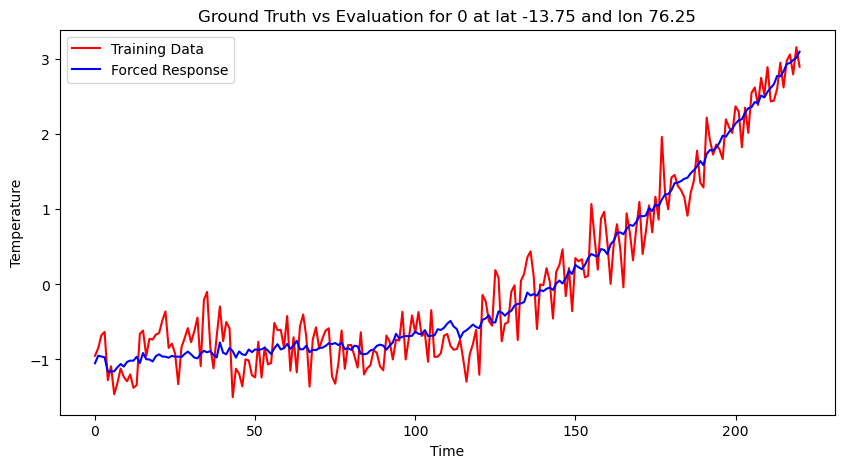

In [12]:
import matplotlib.pyplot as plt

# plot time series in a single grid cell
idx_run = 0
idx_lat = 30
idx_lon = 30
plt.figure(figsize=(10, 5))
plt.plot(dic_data_yearly['CESM2'][0,:,idx_lat,idx_lon], label='Training Data', color='red')
plt.plot(dic_forced_response_yearly['CESM2'][0,:,idx_lat,idx_lon], label='Forced Response', color='blue')
plt.title(f'Ground Truth vs Evaluation for {idx_run} at lat {latitude[idx_lat]} and lon {longitude[idx_lon]}')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.show()

In [13]:
# compute the variance of anomaly per climate model and standardize
means_yearly = {}
vars_yearly = {}
vars = {}
means = {}

# for each model, compute the variance of the anomaly
for dir in DIR_LIST:
    print(f'Computing variance for {dir}')
    # means_yearly[dir] = np.nanmean(dic_data_yearly[dir], axis=0)
    means_yearly[dir] =  np.zeros((dic_data_yearly[dir].shape[1], dic_data_yearly[dir].shape[2], dic_data_yearly[dir].shape[3]), dtype=np.float32)
    vars_yearly[dir] = np.nanvar(dic_data_yearly[dir], axis=0)
    vars[dir] = np.nanvar(dic_data[dir], axis=0)
    means[dir] = np.zeros((dic_data[dir].shape[1], dic_data[dir].shape[2], dic_data[dir].shape[3]), dtype=np.float32)


# normalize the data
# dic_data_tmp = normalize_data(dic_data, means, vars)
# dic_forced_response_tmp = normalize_data(dic_forced_response, means, vars)

dic_data_yearly_tmp = normalize_data(dic_data_yearly, means_yearly, vars_yearly)
dic_forced_response_yearly_tmp= normalize_data(dic_forced_response_yearly, means_yearly, vars_yearly)

Computing variance for MPI-ESM1-2-LR
Computing variance for CanESM5
Computing variance for MIROC-ES2L
Computing variance for MIROC6


Computing variance for CESM2


/home/vcohen/.conda/envs/cope/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1741: RuntimeWarning: invalid value encountered in subtract
  np.subtract(arr, avg, out=arr, casting='unsafe', where=where)
/tmp/ipykernel_34908/456926308.py:14: RuntimeWarning: divide by zero encountered in divide
  normalized_data[key] = (data[key] - means[key]) / np.sqrt(vars[key])


In [14]:
# train the models on yearly data
# compute training set and test set

x_train_yearly, y_train_yearly  = merge_training_data(dic_data_yearly,dic_forced_response_yearly,dtype=torch.float32)
x_train_yearly_tmp, y_train_yearly_tmp  = merge_training_data(dic_data_yearly_tmp,dic_forced_response_yearly_tmp,dtype=torch.float32)

x_yearly, y_yearly = reshape_training_data(dic_data_yearly,dic_forced_response_yearly,dtype=torch.float32)

  x_train shape: torch.Size([6630, 10368])
  x_train shape: torch.Size([12155, 10368])
  x_train shape: torch.Size([18785, 10368])
  x_train shape: torch.Size([29835, 10368])
  x_train shape: torch.Size([40885, 10368])
  x_train shape: torch.Size([6630, 10368])
  x_train shape: torch.Size([12155, 10368])
  x_train shape: torch.Size([18785, 10368])
  x_train shape: torch.Size([29835, 10368])
  x_train shape: torch.Size([40885, 10368])
  x_train shape: torch.Size([30, 221, 10368])
  y_train shape: torch.Size([30, 221, 10368])
  x_train shape: torch.Size([25, 221, 10368])
  y_train shape: torch.Size([25, 221, 10368])
  x_train shape: torch.Size([30, 221, 10368])
  y_train shape: torch.Size([30, 221, 10368])
  x_train shape: torch.Size([50, 221, 10368])
  y_train shape: torch.Size([50, 221, 10368])
  x_train shape: torch.Size([50, 221, 10368])
  y_train shape: torch.Size([50, 221, 10368])


In [15]:
# Evaluate the model on test data
x_test = torch.from_numpy(data_test).to(torch.float32).reshape(data_test.shape[0],data_test.shape[1],data_test.shape[2]*data_test.shape[3])
y_test = torch.from_numpy(data_ground_truth_test).to(torch.float32).reshape(data_test.shape[0],data_test.shape[1],data_test.shape[2]*data_test.shape[3])

In [16]:
# add the new nan indices
# record nan indices as the union of nans on each map
nan_idx_test = nan_idx.copy()

for idx_r in range(x_test.shape[0]):

    nan_idx_test = list(set(nan_idx_test) | set(list(np.where(x_test[idx_r,0,:].ravel() < -1e10 )[0])))    
    # define not nan indices (useful to ease the computations)
notnan_idx_test = list(set(list(range(x_test.shape[2]))) - set(nan_idx_test))


# replace the nan index by Nans
notnan_idx = notnan_idx_test
nan_idx = nan_idx_test

In [17]:
# replace the nan index by Nans
x_train_yearly[:,nan_idx] = float('nan')
x_train_yearly_tmp[:,nan_idx] = float('nan')
x_test[:,:,nan_idx] = float('nan')

y_train_yearly[:,nan_idx] = float('nan')
y_train_yearly_tmp[:,nan_idx] = float('nan')
y_test[:,:,nan_idx] = float('nan')

In [18]:
# we add the saptial mean as indicator of the time index, this can help the model to learn the temporal dynamics
x_train_yearly_new = np.c_[x_train_yearly,np.zeros(x_train_yearly.shape[0])]
x_train_yearly_new[:,-1] = np.nanmean(x_train_yearly, axis=1)

y_train_yearly_new = np.c_[y_train_yearly,np.zeros(y_train_yearly.shape[0])]
y_train_yearly_new[:,-1] = np.nanmean(y_train_yearly, axis=1)

x_train_yearly_new = torch.from_numpy(x_train_yearly_new).to(torch.float32)
y_train_yearly_new = torch.from_numpy(y_train_yearly_new).to(torch.float32)

x_train_yearly_new[:,nan_idx] = float('nan')
y_train_yearly_new[:,nan_idx] = float('nan')

In [19]:
x_test_new = torch.zeros((x_test.shape[0], x_test.shape[1], x_test.shape[2]+1), dtype=torch.float32)
for i in range(x_test.shape[0]):
    x_test_new[i,:,:-1] = x_test[i,:,:]
    x_test_new[i,:,-1] = torch.nanmean(x_test[i,:,:], axis=1)

In [20]:
notnan_idx_new = notnan_idx.copy()
notnan_idx_new.append(x_test.shape[2])

In [21]:
from algorithms import ridge_regression, ridge_regression_low_rank


# penalty parameters
lambda_tmp = 5000.0


# ridge regression
w_ridge = torch.zeros((x_train_yearly.shape[1], y_train_yearly.shape[1]), dtype=torch.float32)
w_ridge[np.ix_(notnan_idx,notnan_idx)] = ridge_regression(x_train_yearly[:,notnan_idx], y_train_yearly[:,notnan_idx], lambda_= lambda_tmp, verbose=True, dtype=torch.float32)

# low rank regression
U,S,V = torch.linalg.svd(x_train_yearly[:,notnan_idx]@w_ridge[np.ix_(notnan_idx,notnan_idx)],full_matrices=False)

rank = 3
w_ridge_low_rank = torch.zeros((x_train_yearly.shape[1], y_train_yearly.shape[1]), dtype=torch.float32)
w_ridge_low_rank[np.ix_(notnan_idx,notnan_idx)] = w_ridge[np.ix_(notnan_idx,notnan_idx)] @ V[:rank,:].T@V[:rank,:]

Loss function:  136504.078125


In [22]:
# penalty parameters
lambda_tmp = 5000.0


# ridge regression on the new data
w_ridge_new = torch.zeros((x_train_yearly_new.shape[1], y_train_yearly_new.shape[1]), dtype=torch.float32)
w_ridge_new[np.ix_(notnan_idx_new,notnan_idx_new)] = ridge_regression(x_train_yearly_new[:,notnan_idx_new], y_train_yearly_new[:,notnan_idx_new], lambda_= lambda_tmp, verbose=True, dtype=torch.float32)


# low rank regression on the new data
U,S,V = torch.linalg.svd(x_train_yearly_new[:,notnan_idx_new]@w_ridge_new[np.ix_(notnan_idx_new,notnan_idx_new)],full_matrices=False)


rank = 3
w_ridge_low_rank_new = torch.zeros((x_train_yearly_new.shape[1], y_train_yearly_new.shape[1]), dtype=torch.float32)
w_ridge_low_rank_new[np.ix_(notnan_idx_new,notnan_idx_new)] = w_ridge_new[np.ix_(notnan_idx_new,notnan_idx_new)] @ V[:rank,:].T@V[:rank,:]

Loss function:  136504.140625


In [23]:
# preditcion on test data
y_pred_new = torch.zeros((x_test_new.shape[0], x_test_new.shape[1], x_test_new.shape[2]), dtype=torch.float32)
y_pred_new[:,:,notnan_idx_new] = x_test_new[:,:,notnan_idx_new] @ w_ridge_new[np.ix_(notnan_idx_new,notnan_idx_new)]

# prediction with low rank ridge regression
y_pred_lr_new = torch.zeros((x_test_new.shape[0], x_test_new.shape[1], x_test_new.shape[2]), dtype=torch.float32)
y_pred_lr_new[:,:,notnan_idx_new] = x_test_new[:,:,notnan_idx_new] @ w_ridge_low_rank_new[np.ix_(notnan_idx_new,notnan_idx_new)]


rmse_new = torch.sqrt(torch.nanmean((y_pred_lr_new[:,:,:-1] - y_test) ** 2,axis=(1,2))).detach().numpy()
rmse_low_rank_new = torch.sqrt(torch.nanmean((y_pred_lr_new[:,:,:-1] - y_test) ** 2,axis=(1,2))).detach().numpy()

print(f'MSE Ridge Regression: {rmse_new}')
print(f'MSE Low Rank Ridge Regression: {rmse_low_rank_new}')

MSE Ridge Regression: [0.27787936 0.22030391 0.30172992 0.21852069 0.19555774 0.1608747
 0.21501407 0.16422866 0.17355128 0.267422  ]
MSE Low Rank Ridge Regression: [0.27787936 0.22030391 0.30172992 0.21852069 0.19555774 0.1608747
 0.21501407 0.16422866 0.17355128 0.267422  ]


In [24]:
# preditcion on test data
y_pred = torch.zeros((x_test.shape[0], x_test.shape[1], x_test.shape[2]), dtype=torch.float32)
y_pred[:,:,notnan_idx] = x_test[:,:,notnan_idx] @ w_ridge[np.ix_(notnan_idx,notnan_idx)]

# prediction with low rank ridge regression
y_pred_lr = torch.zeros((x_test.shape[0], x_test.shape[1], x_test.shape[2]), dtype=torch.float32)
y_pred_lr[:,:,notnan_idx] = x_test[:,:,notnan_idx] @ w_ridge_low_rank[np.ix_(notnan_idx,notnan_idx)]


rmse = torch.sqrt(torch.nanmean((y_pred - y_test) ** 2,axis=(1,2))).detach().numpy()
rmse_low_rank = torch.sqrt(torch.nanmean((y_pred_lr - y_test) ** 2,axis=(1,2))).detach().numpy()

print(f'MSE Ridge Regression: {rmse}')
print(f'MSE Low Rank Ridge Regression: {rmse_low_rank}')

MSE Ridge Regression: [0.2959516  0.22964579 0.30071625 0.22488247 0.20130669 0.16434415
 0.21748255 0.16663402 0.18413296 0.2739113 ]
MSE Low Rank Ridge Regression: [0.27787885 0.22030398 0.30172965 0.21852069 0.19555776 0.16087465
 0.21501413 0.16422868 0.1735513  0.26742247]


In [25]:
data_estimates_tmp = data_estimates.reshape(data_estimates.shape[0],data_estimates.shape[1],data_estimates.shape[2],data_estimates.shape[3]*data_estimates.shape[4])
data_ground_truth_test_tmp = data_ground_truth_test.reshape(data_ground_truth_test.shape[0],data_ground_truth_test.shape[1],data_ground_truth_test.shape[2]*data_ground_truth_test.shape[3])

In [31]:
# compute mse of the other estimates
mse_estimates = np.zeros((data_estimates.shape[0],data_estimates.shape[1]))

for idx_r in range(data_estimates.shape[0]):
    mse_estimates[idx_r,:] = np.sqrt(np.nanmean((data_estimates_tmp[idx_r,:,:,notnan_idx].transpose(1,2,0) - data_ground_truth_test_tmp[:,:,notnan_idx]) ** 2,axis=(1,2))) 
    print(f'  MSE estimates: {mse_estimates[idx_r,:]}')

  MSE estimates: [0.28536513 0.26515353 0.25599292 0.45298886 0.23926461 0.2204444
 0.30716702 0.23084365 0.25732377 0.26514444]
  MSE estimates: [0.23774445 0.24668823 0.23391834 0.3926945  0.23955144 0.19345807
 0.2651298  0.19819234 0.28410912 0.2263207 ]
  MSE estimates: [0.21381061 0.22568692 0.20230572 0.43880808 0.19529693 0.18315861
 0.25151205 0.18645662 0.24814224 0.24714004]
  MSE estimates: [0.24704845 0.38486251 0.33090809 0.25517273 0.32583562 0.24116412
 0.27897114 0.19205542 0.21070795 0.36878666]
  MSE estimates: [0.18165264 0.18075012 0.21267536 0.24434634 0.19196312 0.16802482
 0.23851666 0.18137756 0.1821266  0.19239703]
  MSE estimates: [0.15750575 0.15559337 0.18167152 0.20051481 0.16405053 0.13389991
 0.20613751 0.12958355 0.18462546 0.16874719]
  MSE estimates: [0.18048717 0.17867574 0.20049781 0.38370138 0.17531215 0.1431367
 0.22668715 0.15106058 0.20234805 0.21202564]
  MSE estimates: [0.17293404 0.19291571 0.20266698 0.39176118 0.17016703 0.2244392
 0.244776

In [27]:
# get the statistics of the estimates and the predictions
stats_mse_estimates = {}
stats_mse_estimates['mean'] = np.zeros(mse_estimates.shape[0]+4)
stats_mse_estimates['median'] = np.zeros(mse_estimates.shape[0]+4)
stats_mse_estimates['75th'] = np.zeros(mse_estimates.shape[0]+4)
stats_mse_estimates['90th'] = np.zeros(mse_estimates.shape[0]+4)
stats_mse_estimates['95th'] = np.zeros(mse_estimates.shape[0]+4)
stats_mse_estimates['worst-case'] = np.zeros(mse_estimates.shape[0]+4)
stats_mse_estimates['variance'] = np.zeros(mse_estimates.shape[0]+4)


for idx_r in range(data_estimates.shape[0]):
    # compute the mse of the estimates

    stats_mse_estimates['mean'][idx_r] = np.mean(mse_estimates[idx_r,:], axis=0)
    stats_mse_estimates['median'][idx_r] = np.median(mse_estimates[idx_r,:], axis=0)
    stats_mse_estimates['75th'][idx_r] = np.quantile(mse_estimates[idx_r,:], 0.75, axis=0)
    stats_mse_estimates['90th'][idx_r] = np.quantile(mse_estimates[idx_r,:], 0.90, axis=0)
    stats_mse_estimates['95th'][idx_r] = np.quantile(mse_estimates[idx_r,:], 0.95, axis=0)
    stats_mse_estimates['worst-case'][idx_r] = np.max(mse_estimates[idx_r,:], axis=0)
    stats_mse_estimates['variance'][idx_r] = np.var(mse_estimates[idx_r,:], axis=0)



stats_mse_estimates['mean'][data_estimates.shape[0]] = np.mean(rmse, axis=0)
stats_mse_estimates['median'][data_estimates.shape[0]] = np.median(rmse, axis=0)
stats_mse_estimates['75th'][data_estimates.shape[0]] = np.quantile(rmse, 0.75, axis=0)
stats_mse_estimates['90th'][data_estimates.shape[0]] = np.quantile(rmse, 0.90, axis=0)
stats_mse_estimates['95th'][data_estimates.shape[0]] = np.quantile(rmse, 0.95, axis=0)
stats_mse_estimates['worst-case'][data_estimates.shape[0]] = np.max(rmse, axis=0)
stats_mse_estimates['variance'][data_estimates.shape[0]] = np.var(rmse, axis=0)



stats_mse_estimates['mean'][data_estimates.shape[0]+1] = np.mean(rmse_low_rank, axis=0)
stats_mse_estimates['median'][data_estimates.shape[0]+1] = np.median(rmse_low_rank, axis=0)
stats_mse_estimates['75th'][data_estimates.shape[0]+1] = np.quantile(rmse_low_rank, 0.75, axis=0)
stats_mse_estimates['90th'][data_estimates.shape[0]+1] = np.quantile(rmse_low_rank, 0.90, axis=0)
stats_mse_estimates['95th'][data_estimates.shape[0]+1] = np.quantile(rmse_low_rank, 0.95, axis=0)
stats_mse_estimates['worst-case'][data_estimates.shape[0]+1] = np.max(rmse_low_rank, axis=0)
stats_mse_estimates['variance'][data_estimates.shape[0]+1] = np.var(rmse_low_rank, axis=0)



stats_mse_estimates['mean'][data_estimates.shape[0]+2] = np.mean(rmse_new, axis=0)
stats_mse_estimates['median'][data_estimates.shape[0]+2] = np.median(rmse_new, axis=0)
stats_mse_estimates['75th'][data_estimates.shape[0]+2] = np.quantile(rmse_new, 0.75, axis=0)
stats_mse_estimates['90th'][data_estimates.shape[0]+2] = np.quantile(rmse_new, 0.90, axis=0)
stats_mse_estimates['95th'][data_estimates.shape[0]+2] = np.quantile(rmse_new, 0.95, axis=0)
stats_mse_estimates['worst-case'][data_estimates.shape[0]+2] = np.max(rmse_new, axis=0)
stats_mse_estimates['variance'][data_estimates.shape[0]+2] = np.var(rmse_new, axis=0)



stats_mse_estimates['mean'][data_estimates.shape[0]+3] = np.mean(rmse_low_rank_new, axis=0)
stats_mse_estimates['median'][data_estimates.shape[0]+3] = np.median(rmse_low_rank_new, axis=0)
stats_mse_estimates['75th'][data_estimates.shape[0]+3] = np.quantile(rmse_low_rank_new, 0.75, axis=0)
stats_mse_estimates['90th'][data_estimates.shape[0]+3] = np.quantile(rmse_low_rank_new, 0.90, axis=0)
stats_mse_estimates['95th'][data_estimates.shape[0]+3] = np.quantile(rmse_low_rank_new, 0.95, axis=0)
stats_mse_estimates['worst-case'][data_estimates.shape[0]+3] = np.max(rmse_low_rank_new, axis=0)
stats_mse_estimates['variance'][data_estimates.shape[0]+3] = np.var(rmse_low_rank_new, axis=0)


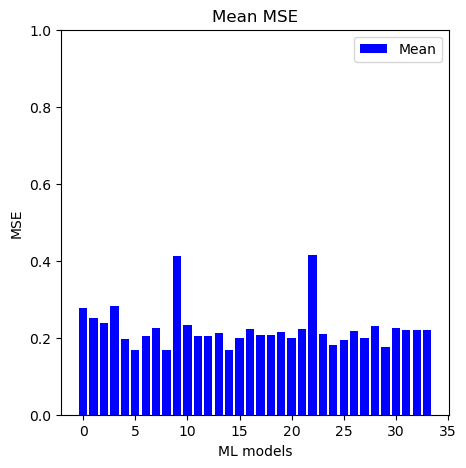

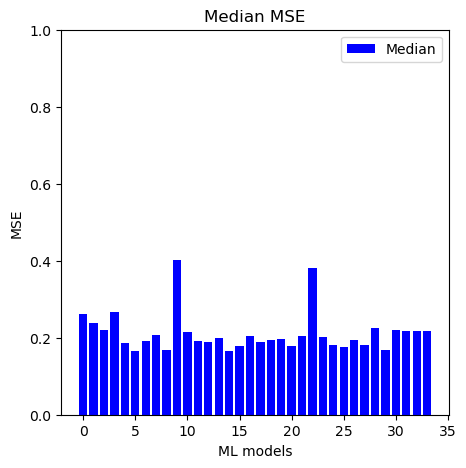

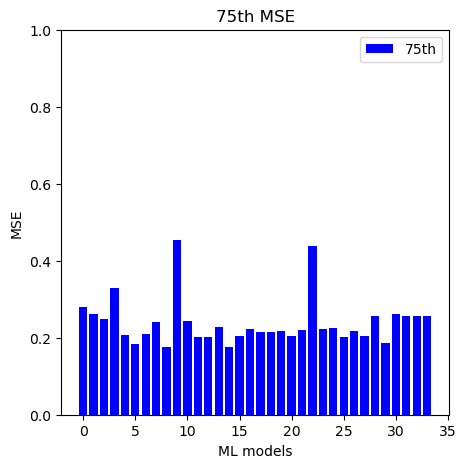

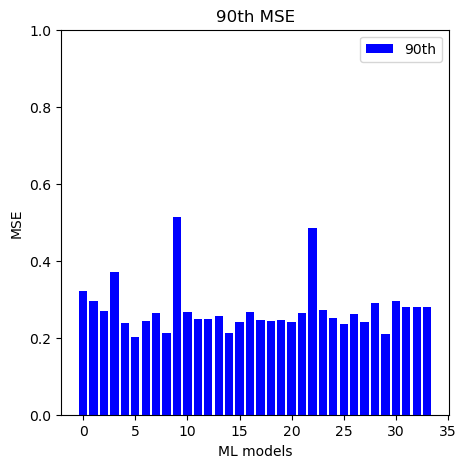

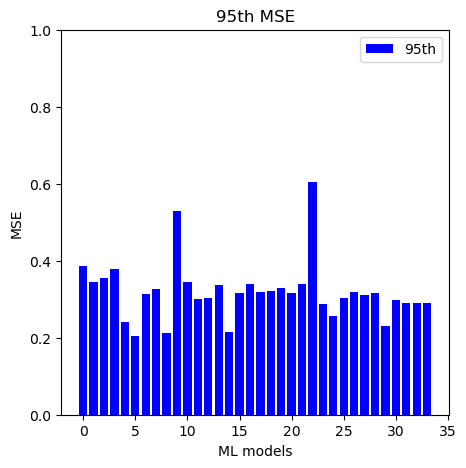

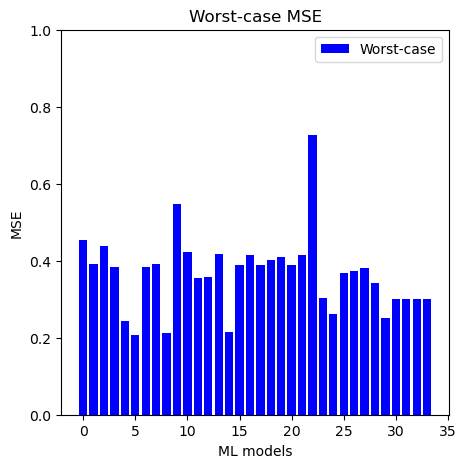

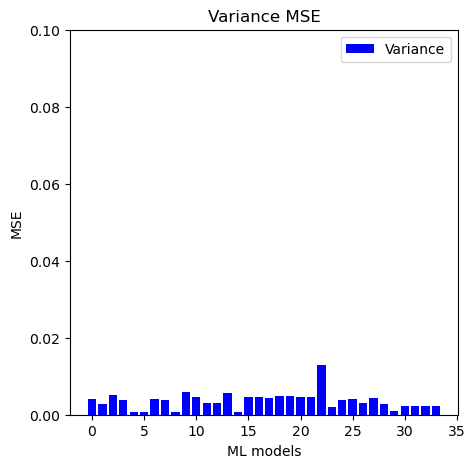

In [28]:
# display the statistica as bar plot

#plot the mean
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['mean'])), stats_mse_estimates['mean'], color='blue', label='Mean')
plt.title('Mean MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show() 

#plot the median
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['median'])), stats_mse_estimates['median'], color='blue', label='Median')
plt.title('Median MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show() 

#plot the 75th
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['75th'])), stats_mse_estimates['75th'], color='blue', label='75th')
plt.title('75th MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()

#plot the 90th
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['90th'])), stats_mse_estimates['90th'], color='blue', label='90th')
plt.title('90th MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()

#plot the 95th
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['95th'])), stats_mse_estimates['95th'], color='blue', label='95th')
plt.title('95th MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()

# plot the worst-case
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['worst-case'])), stats_mse_estimates['worst-case'], color='blue', label='Worst-case')
plt.title('Worst-case MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()


# plot the variance
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['variance'])), stats_mse_estimates['variance'], color='blue', label='Variance')
plt.title('Variance MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0,0.1)
plt.legend()
plt.show()

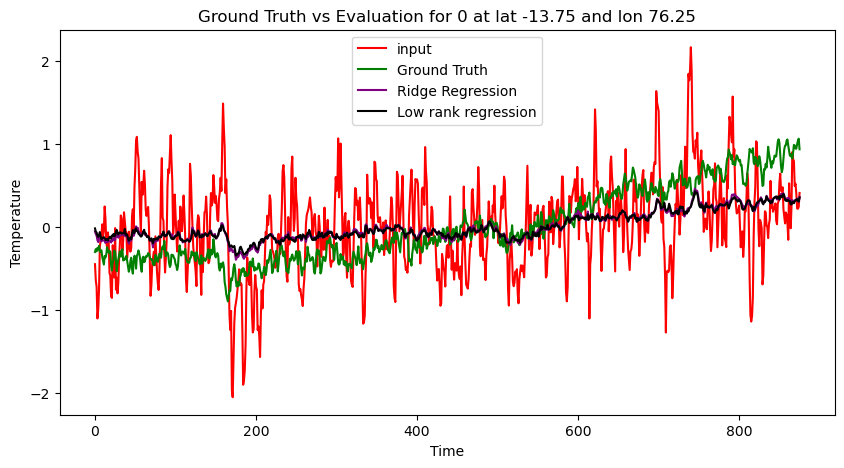

In [29]:
# plot time series in a single grid cell
idx_lat = 30
idx_lon = 30
plt.figure(figsize=(10, 5))
# plt.plot(dic_data['CESM2'][0,:,idx_lat,idx_lon], label='Training Data', color='red')
plt.plot(x_test.reshape(10,y_test.shape[1],latitude.shape[0],longitude.shape[0])[2,:,idx_lat,idx_lon], label='input', color='red')
plt.plot(y_test.reshape(10,y_test.shape[1],latitude.shape[0],longitude.shape[0])[2,:,idx_lat,idx_lon], label='Ground Truth', color='green')
plt.plot(y_pred.reshape(10,y_pred.shape[1],latitude.shape[0],longitude.shape[0])[2,:,idx_lat,idx_lon], label='Ridge Regression', color='purple')
plt.plot(y_pred_lr.reshape(10,y_pred_lr.shape[1],latitude.shape[0],longitude.shape[0])[2,:,idx_lat,idx_lon], label='Low rank regression', color='black')
# plt.plot(y_pred_trace.reshape(10,y_pred.shape[1],latitude.shape[0],longitude.shape[0])[2,:,idx_lat,idx_lon], label='Trace norm regression', color='orange')
plt.title(f'Ground Truth vs Evaluation for {idx_run} at lat {latitude[idx_lat]} and lon {longitude[idx_lon]}')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.show()